In [58]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from astroML.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

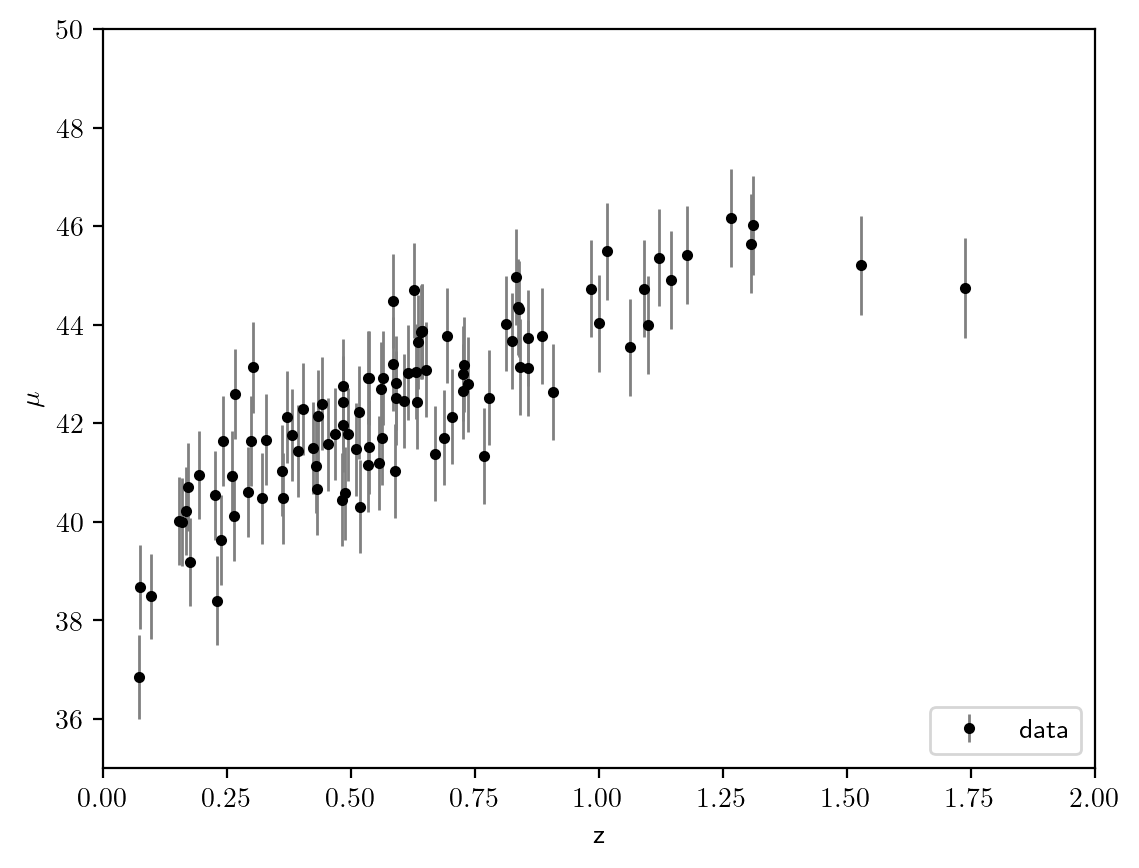

In [59]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [60]:
X = z_sample[:,np.newaxis]
y = mu_sample
y_err = dmu
Xgrid = np.linspace(0., 2., 1000)[:,np.newaxis]

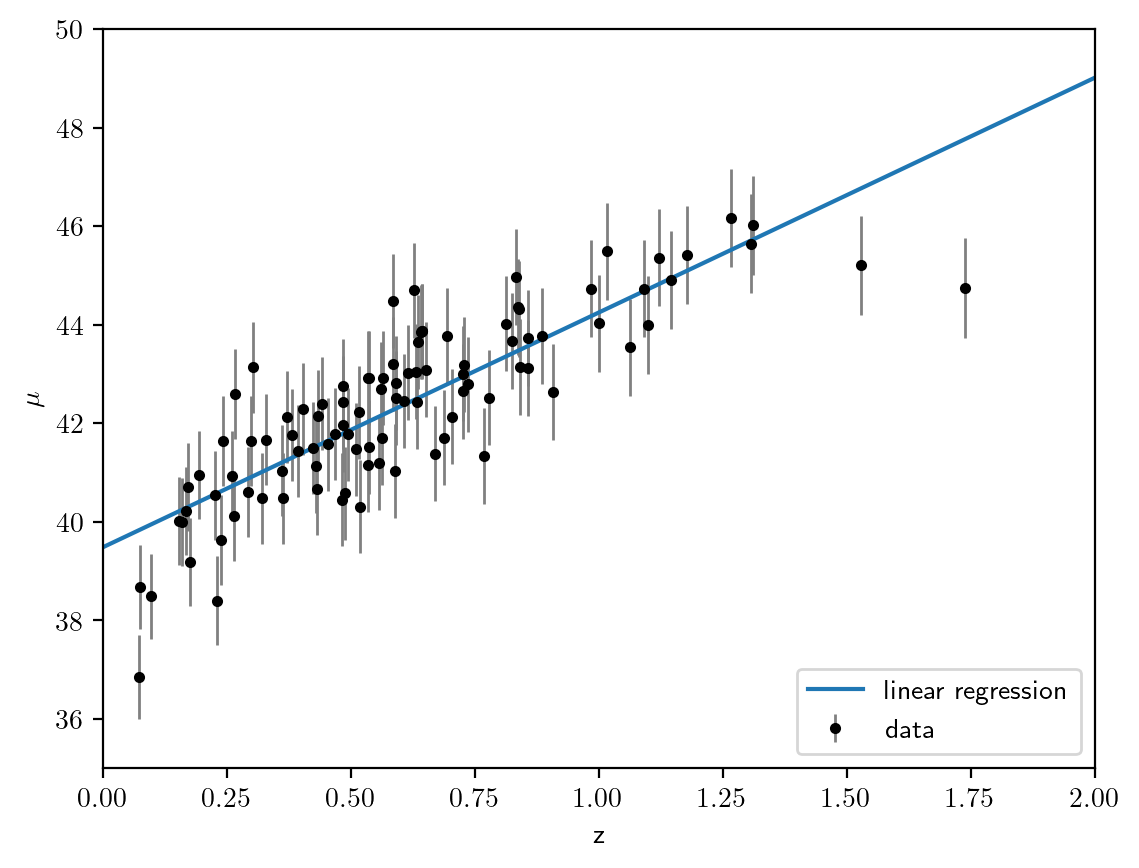

In [61]:
lin_reg = LinearRegression()
lin_reg.fit(X, y, y_err)
y_pred = lin_reg.predict(Xgrid)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(Xgrid, y_pred, label = 'linear regression')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

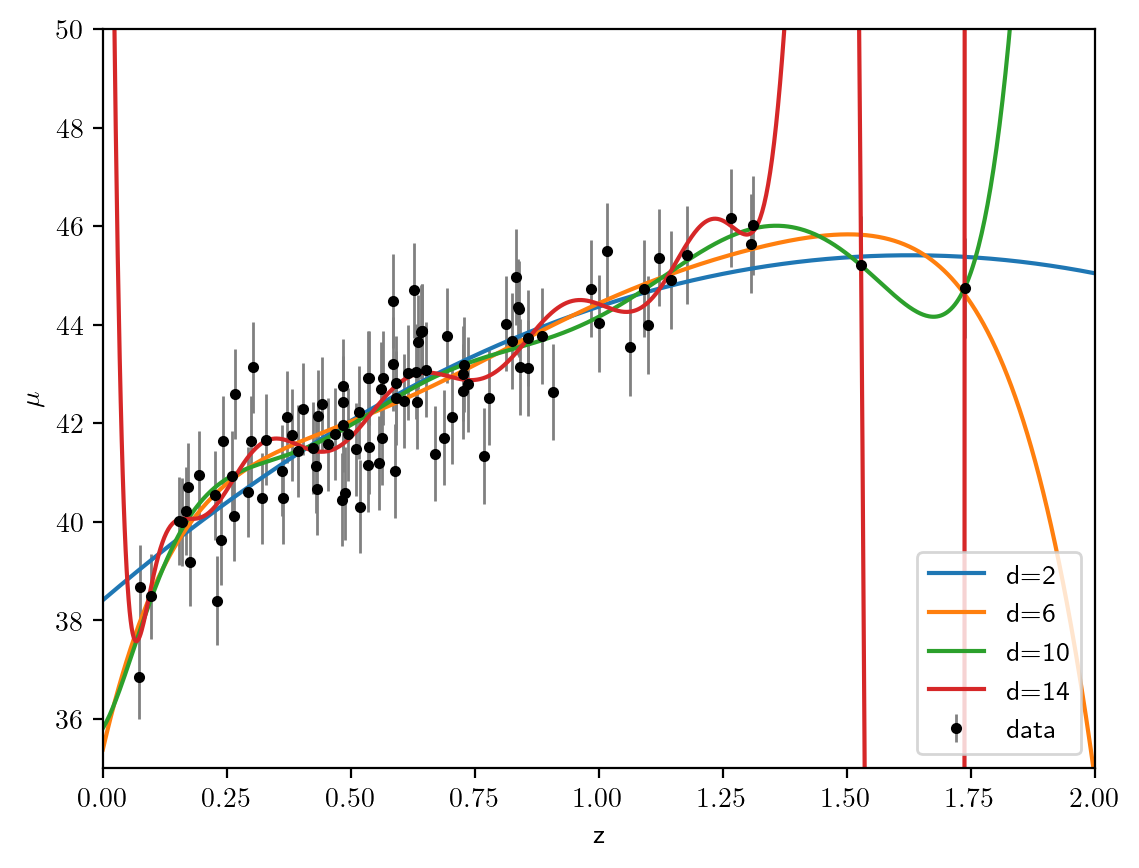

In [62]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0,2)
plt.ylim(35,50);

for d in np.arange(1,15)[1::4]:

    model = PolynomialRegression(d)
    model.fit(X, y, y_err)
    y_pred = model.predict(Xgrid)

    plt.plot(Xgrid, y_pred, label=f'd={d}')

plt.legend(loc='lower right')

d = 2 and d = 6 seem to be good fits -> Occam's razor: going with d = 2

- underfitting: for sure in the linear model (d=1)
- overfitting: for sure in d = 10, d = 14

In [63]:
Xtrain, Xtest, ytrain, ytest, errtrain, errtest = train_test_split(X, y, y_err, train_size=0.8)
print(Xtrain.shape, Xtest.shape)

(80, 1) (20, 1)


In [70]:
def kfold_cv(Xtrain, ytrain, errtrain, deg):
    K = 10 # number of folds
    eps_cv = np.zeros(K)
    eps_tr = np.zeros(K)
    n = len(Xtrain)
    model = PolynomialRegression(deg)

    for k in range(K):
        Xtr = Xtrain.copy()
        ytr = ytrain.copy()
        errtr = errtrain.copy()

        start_val = k*int(n/K)
        stop_val = int(n/K)*(k+1)

        Xval = Xtr[start_val:stop_val]
        yval = ytr[start_val:stop_val]
        errval = errtr[start_val:stop_val]
        Xtr = np.delete(Xtr, np.arange(start_val,stop_val), axis = 0)
        ytr = np.delete(ytr, np.arange(start_val,stop_val))
        errtr = np.delete(errtr, np.arange(start_val, stop_val))

        model.fit(Xtr, ytr, errtr)
        ypred_tr = model.predict(Xtr)
        ypred_val = model.predict(Xval)

        eps_tr[k] = np.sqrt(np.mean((ypred_tr - ytr) ** 2))
        eps_cv[k] = np.sqrt(np.mean((ypred_val - yval) ** 2))

    return np.mean(eps_tr), np.mean(eps_cv)

In [77]:
deg_max = 15
degrees = np.arange(1, deg_max, dtype = int)

tr_loss = np.zeros(deg_max-1)
cv_loss = np.zeros_like(tr_loss)
for d in degrees:
    tr_loss[d-1], cv_loss[d-1] = kfold_cv(Xtrain, ytrain, errtrain, d) 
                    

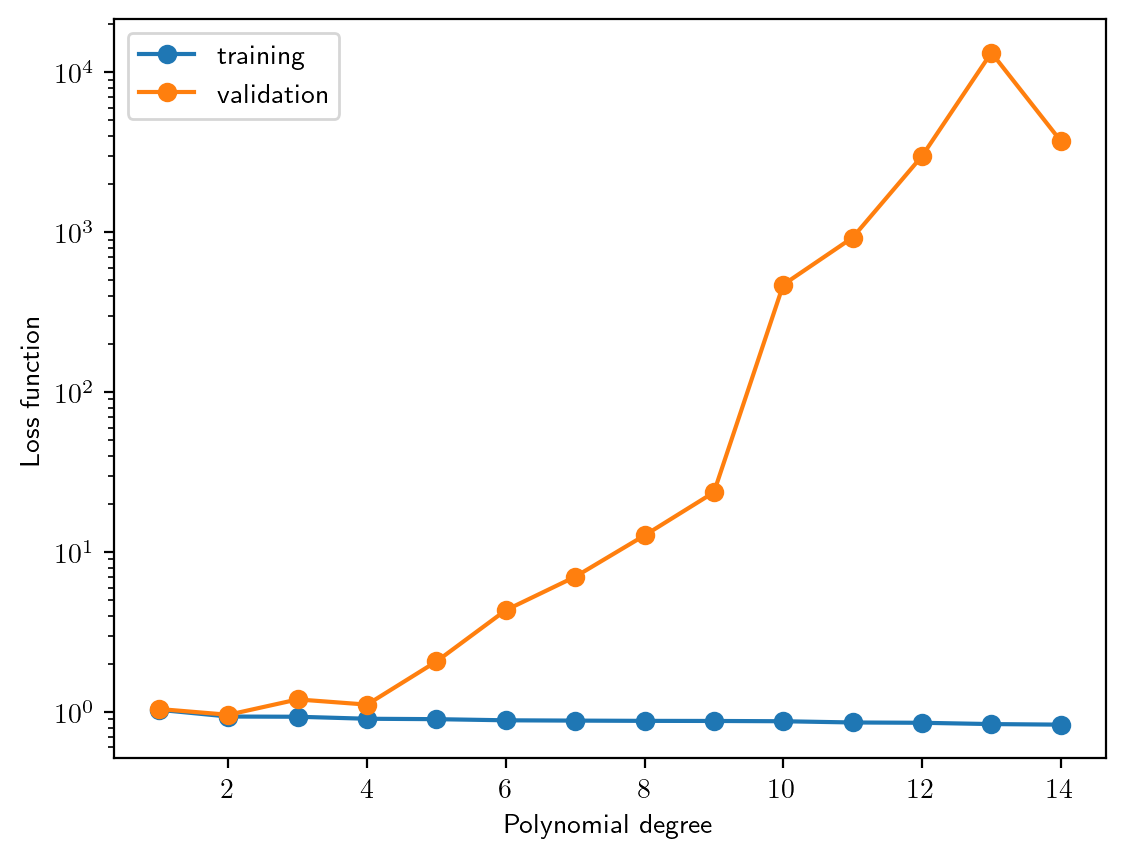

In [84]:
degrees = np.arange(1, deg_max)

plt.plot(degrees, tr_loss, label = 'training', marker = 'o')
plt.plot(degrees, cv_loss, label = 'validation', marker = 'o')
plt.yscale('log')
plt.xlabel('Polynomial degree')
plt.ylabel('Loss function')
plt.legend()

In [86]:
print(f'Best fit: polynomial of degree {np.argmin(cv_loss)+1}')

Best fit: polynomial of degree 2


In [93]:
model = PolynomialRegression(np.argmin(cv_loss)+1)
model.fit(Xtrain, ytrain, errtrain)
ypred = model.predict(Xtest)
test_err = np.sqrt(np.mean((ypred - ytest) ** 2))

In [94]:
print('Best model coefficients:', model.coef_)
print('Test error:', test_err)

Best model coefficients: [38.17849375  9.20929654 -2.9475336 ]
Test error: 0.7625234365154102
